# Final Project — Data Science in Cyber
## Website Phishing Detection — Reproduction and Critical Evaluation

This notebook reproduces and critically evaluates the Kaggle notebook **"Website Phishing Detection ML Project"** using the same dataset as the original notebook, which loads it as:

```python
df = pd.read_csv("../input/website-phishing-data-set/Website Phishing.csv")
```

The dataset contains 1,353 encoded website records, 9 predictive features, and a 3-class target:
- `-1` = phishing
- `0` = suspicious
- `1` = legitimate
.

# Section 1 — Setup and Data Loading

This section imports the required Python libraries and loads the dataset.

In [21]:
import os
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    matthews_corrcoef, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


In [22]:
def evaluate_model(name, y_true, y_pred, y_prob):
    """Compute classification metrics for one model.

    Parameters
    ----------
    name : str   Model name.
    y_true       True class labels.
    y_pred       Predicted class labels.
    y_prob       Predicted class probabilities.

    Returns
    -------
    dict  Metric names and values.
    """
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision_weighted": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall_weighted": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1_weighted": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "F2_weighted": fbeta_score(y_true, y_pred, beta=2, average="weighted", zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "ROC_AUC_weighted_OVR": roc_auc_score(y_true, y_prob, multi_class="ovr", average="weighted")
    }

print("evaluate_model function defined.")

evaluate_model function defined.


In [23]:
# Look for the dataset in the working directory first, then in the
# Colab default upload location (/content/), so the notebook runs the
# same way locally, in Jupyter, or in Google Colab without editing paths.
CSV_CANDIDATES = [
    "Website Phishing.csv",
    "Website_Phishing.csv",
    "/content/Website Phishing.csv",
    "/content/Website_Phishing.csv",
]
ZIP_CANDIDATES = [
    "website-phishing-data-set.zip",
    "/content/website-phishing-data-set.zip",
]

csv_path = next((p for p in CSV_CANDIDATES if os.path.exists(p)), None)

if csv_path is None:
    zip_path = next((p for p in ZIP_CANDIDATES if os.path.exists(p)), None)
    if zip_path is not None:
        with zipfile.ZipFile(zip_path) as z:
            csv_names = [n for n in z.namelist() if n.lower().endswith(".csv")]
            z.extractall(".")
        if csv_names:
            csv_path = csv_names[0]

if csv_path is None:
    raise FileNotFoundError(
        "Could not find 'Website Phishing.csv'. Place the CSV (or the Kaggle "
        "ZIP containing it) in the working directory, or in /content/ if running "
        "in Google Colab."
    )

df = pd.read_csv(csv_path)

# Clean column names to make later code easier and consistent
df.columns = df.columns.str.strip().str.lower()

print("Dataset loaded successfully from:", csv_path)
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully from: Website Phishing.csv
Shape: (1353, 10)


,sfh,popupwidnow,sslfinal_state,request_url,url_of_anchor,web_traffic,url_length,age_of_domain,having_ip_address,result
0,1,-1,1,-1,-1,1,1,1,0,0
1,-1,-1,-1,-1,-1,0,1,1,1,1
2,1,-1,0,0,-1,0,-1,1,0,1
3,1,0,1,-1,-1,0,1,1,0,0
4,-1,-1,1,-1,0,0,-1,1,0,1


## Data Loading Findings

The dataset contains 1,353 rows and 10 columns: 9 predictive features and one target column (`result`). The original feature values are encoded using small integer values such as `-1`, `0`, and `1`. This means the dataset is already numerically encoded, but the values are categorical/ordinal indicators rather than raw continuous measurements.

The dataset is already preprocessed and encoded, so no additional categorical encoding is required before model training. However, the encoded values should be interpreted as categorical or ordinal indicators rather than continuous numerical measurements.

# Section 2 — Data Inspection and Quality Checks

This section checks feature types, missing values, duplicate rows, constant features, duplicate feature columns, and whether column names make sense.

In [24]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nIndex information:")
print(df.index)

print("\nFeature types:")
feature_types = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str),
    "unique_values": [sorted(df[col].unique().tolist()) for col in df.columns],
    "num_unique_values": [df[col].nunique() for col in df.columns]
})

display(feature_types)

Number of rows: 1353
Number of columns: 10

Column names:
['sfh', 'popupwidnow', 'sslfinal_state', 'request_url', 'url_of_anchor', 'web_traffic', 'url_length', 'age_of_domain', 'having_ip_address', 'result']

Index information:
RangeIndex(start=0, stop=1353, step=1)

Feature types:


,column,dtype,unique_values,num_unique_values
sfh,sfh,int64,"[-1, 0, 1]",3
popupwidnow,popupwidnow,int64,"[-1, 0, 1]",3
sslfinal_state,sslfinal_state,int64,"[-1, 0, 1]",3
request_url,request_url,int64,"[-1, 0, 1]",3
url_of_anchor,url_of_anchor,int64,"[-1, 0, 1]",3
web_traffic,web_traffic,int64,"[-1, 0, 1]",3
url_length,url_length,int64,"[-1, 0, 1]",3
age_of_domain,age_of_domain,int64,"[-1, 1]",2
having_ip_address,having_ip_address,int64,"[0, 1]",2
result,result,int64,"[-1, 0, 1]",3


In [25]:
feature_columns = [col for col in df.columns if col != "result"]

print("Missing values per column:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nExact duplicate rows:", df.duplicated().sum())

constant_features = [
    col for col in feature_columns
    if df[col].nunique() == 1
]

print("\nConstant features:", constant_features)

duplicate_feature_pairs = []
for i, col1 in enumerate(feature_columns):
    for col2 in feature_columns[i + 1:]:
        if df[col1].equals(df[col2]):
            duplicate_feature_pairs.append((col1, col2))

print("\nDuplicate feature-column pairs:", duplicate_feature_pairs)

Missing values per column:


,missing_values
sfh,0
popupwidnow,0
sslfinal_state,0
request_url,0
url_of_anchor,0
web_traffic,0
url_length,0
age_of_domain,0
having_ip_address,0
result,0



Total missing values: 0

Exact duplicate rows: 629

Constant features: []

Duplicate feature-column pairs: []


No features were removed because no constant or duplicated feature column

The column names are meaningful because they correspond to phishing-related website characteristics such as SSL state, request URLs, anchor URLs, domain age, and IP usage. After converting them to lowercase, they are easier to reference consistently throughout the notebook.

The dataset uses the default integer row index (0–1352). This is appropriate because the dataset does not contain a unique website identifier or timestamp. Therefore, the index functions only as a row identifier and carries no predictive information.

In [26]:
X_features = df.drop(columns=["result"])

feature_pattern_counts = df.duplicated(subset=X_features.columns).sum()

label_counts_per_pattern = df.groupby(list(X_features.columns))["result"].nunique()
conflicting_patterns = label_counts_per_pattern[label_counts_per_pattern > 1]

print("Duplicate feature patterns:", feature_pattern_counts)
print("Unique feature patterns:", df.drop_duplicates(subset=X_features.columns).shape[0])
print("Feature patterns with conflicting class labels:", len(conflicting_patterns))

if len(conflicting_patterns) > 0:
    print("\nExample conflicting feature patterns:")
    conflict_examples = (
        df.groupby(list(X_features.columns))["result"]
        .agg(lambda s: sorted(s.unique()))
        .reset_index()
    )
    display(conflict_examples[conflict_examples["result"].apply(len) > 1].head())

Duplicate feature patterns: 677
Unique feature patterns: 676
Feature patterns with conflicting class labels: 48

Example conflicting feature patterns:


,sfh,popupwidnow,sslfinal_state,request_url,url_of_anchor,web_traffic,url_length,age_of_domain,having_ip_address,result
39,-1,-1,0,-1,-1,-1,-1,1,0,"[0, 1]"
44,-1,-1,0,-1,-1,0,-1,1,0,"[-1, 1]"
56,-1,-1,0,-1,1,-1,0,1,0,"[-1, 1]"
71,-1,-1,0,1,1,-1,0,1,0,"[-1, 1]"
82,-1,-1,1,-1,-1,0,-1,-1,0,"[-1, 1]"


## Data Quality Findings

The dataset has no missing values and no constant or duplicated feature columns. However, it contains many exact duplicate encoded rows. This happens because the dataset has only 9 encoded categorical/ordinal features, so many different websites can share the same feature pattern.

A more important issue is that some identical feature patterns appear with different target labels. This means the features do not fully determine the class. In practice, this limits the maximum achievable performance and makes the suspicious class especially difficult to classify.

For this reason, the notebook keeps the original dataset for reproduction, but also reports a duplicate-aware sensitivity analysis later.

# Section 3 — Class Balance and Prevalence

The target contains three classes:

- `-1`: phishing
- `0`: suspicious
- `1`: legitimate

Class balance matters because cybersecurity datasets often do not match real-world prevalence. In the real world, phishing pages are much rarer than legitimate pages, so high test accuracy on a balanced or curated dataset may be optimistic.

        class_name  count  percentage
result                               
-1        phishing    702       51.88
 0      suspicious    103        7.61
 1      legitimate    548       40.50


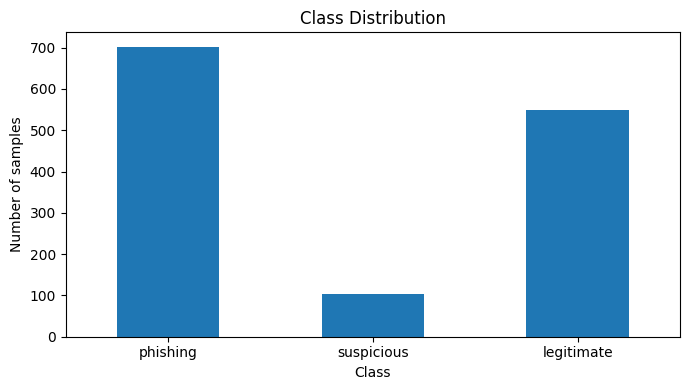

In [27]:
class_names = {-1: "phishing", 0: "suspicious", 1: "legitimate"}
class_counts = df["result"].value_counts().sort_index()
class_percent = (df["result"].value_counts(normalize=True).sort_index() * 100).round(2)

class_summary = pd.DataFrame({
    "class_name": [class_names[i] for i in class_counts.index],
    "count": class_counts.values,
    "percentage": class_percent.values
}, index=class_counts.index)

print(class_summary)

plt.figure(figsize=(7, 4))
class_summary.set_index("class_name")["count"].plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Class Balance Analysis

The dataset is not balanced. The phishing class is the largest, the legitimate class is also large, and the suspicious class is much smaller. This means that overall accuracy alone can be misleading because a model may perform well on the larger classes while performing poorly on the minority suspicious class.

From a cybersecurity perspective, this is reasonable because suspicious websites often represent ambiguous or transitional cases that are more difficult to identify and label consistently.

For phishing detection, recall for the phishing class is especially important because a false negative means that a phishing website is missed. The suspicious class is also important because these websites may require additional investigation before they can be classified confidently.

The original notebook does not explicitly discuss this class distribution or its implications for model evaluation. In this reproduction, weighted evaluation metrics are used to provide a fairer assessment across all three classes.


# Section 4 — Exploratory Data Analysis (EDA)

The dataset contains encoded categorical/ordinal features. Therefore, count plots and crosstabs are more meaningful than continuous histograms.

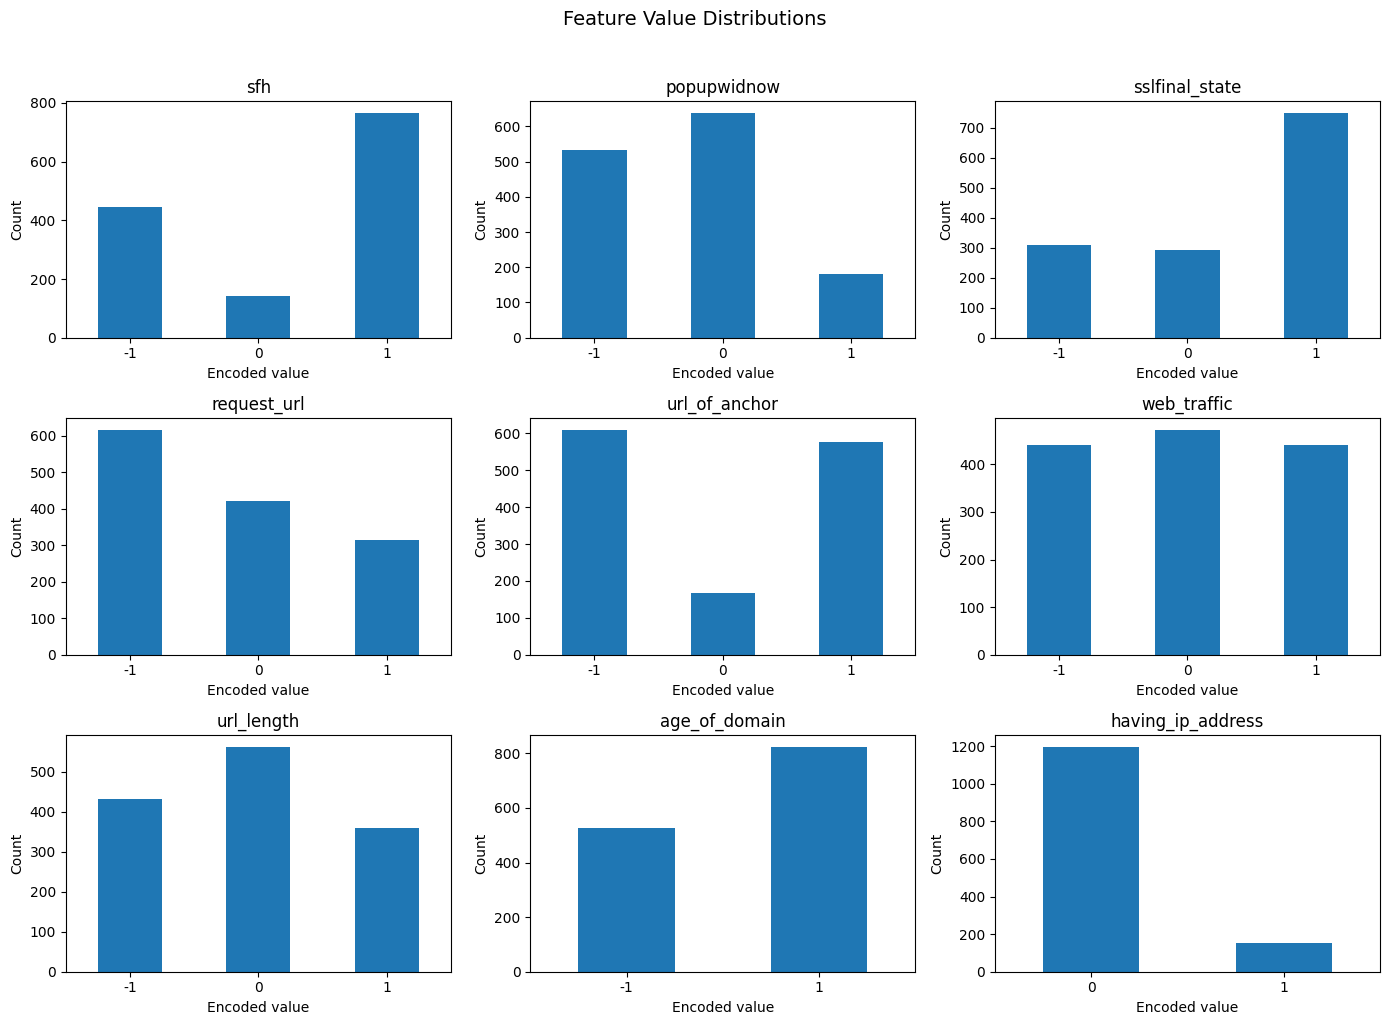

In [28]:
# Feature value distributions.
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, col in zip(axes, feature_columns):
    df[col].value_counts().sort_index().plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Encoded value")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=0)

plt.suptitle("Feature Value Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [29]:
# Mean feature values by class. This gives a quick view of how encoded values differ by target.
group_means = df.groupby("result")[feature_columns].mean().round(3)
group_means.index = [class_names[i] for i in group_means.index]
print("Mean encoded feature values by class:")
display(group_means)

Mean encoded feature values by class:


,sfh,popupwidnow,sslfinal_state,request_url,url_of_anchor,web_traffic,url_length,age_of_domain,having_ip_address
phishing,0.829,0.064,0.707,0.020,0.242,-0.168,0.046,0.410,0.131
suspicious,-0.029,-0.320,0.505,-0.816,-0.301,-0.175,0.350,0.456,0.126
legitimate,-0.469,-0.661,-0.192,-0.423,-0.316,0.248,-0.255,-0.069,0.091


In [30]:
# Crosstab analysis for selected security-relevant features.
for col in ["sfh", "sslfinal_state", "url_of_anchor", "web_traffic", "age_of_domain", "having_ip_address"]:
    print(f"\nCrosstab: {col} vs result")
    ct = pd.crosstab(df[col], df["result"], rownames=[col], colnames=["result"])
    ct = ct.rename(columns=class_names)
    display(ct)


Crosstab: sfh vs result


result,phishing,suspicious,legitimate
sfh,,,
-1,59,46,340
0,2,14,125
1,641,43,83



Crosstab: sslfinal_state vs result


result,phishing,suspicious,legitimate
sslfinal_state,,,
-1,62,10,236
0,82,31,181
1,558,62,131



Crosstab: url_of_anchor vs result


...

result,phishing,suspicious,legitimate
web_traffic,,,
-1,292,50,98
0,236,21,216
1,174,32,234



Crosstab: age_of_domain vs result


result,phishing,suspicious,legitimate
age_of_domain,,,
-1,207,28,293
1,495,75,255



Crosstab: having_ip_address vs result


result,phishing,suspicious,legitimate
having_ip_address,,,
0,610,90,498
1,92,13,50


## Crosstab and Group-By Findings

The crosstab and group-by analyses show that several encoded features have different distributions across phishing, suspicious, and legitimate websites. In particular, `sfh`, `sslfinal_state`, `url_of_anchor`, and `web_traffic` show visible differences between classes. These are meaningful cybersecurity indicators because they describe page structure, SSL behavior, anchor links, and traffic/reputation signals.

# Section 5 — Temporal Feature Analysis

The dataset does not contain timestamps showing when each website was collected. However, `age_of_domain` is a temporal proxy feature because it indicates whether a domain is old or new.

**Note:** This dataset does not contain explicit temporal or time-series features. The feature `age_of_domain` serves as a temporal proxy only. The analysis is therefore treated as a static classification task, not a time-series problem.

age_of_domain value counts:
age_of_domain
-1    528
 1    825
Name: count, dtype: int64

age_of_domain by class:


result,phishing,suspicious,legitimate
age_of_domain,,,
-1,207,28,293
1,495,75,255


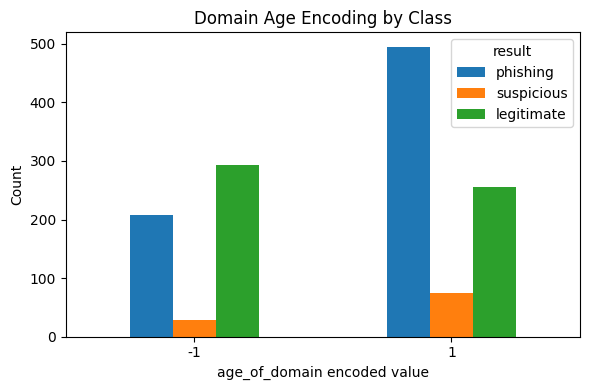

In [31]:
print("age_of_domain value counts:")
print(df["age_of_domain"].value_counts().sort_index())

print("\nage_of_domain by class:")
display(pd.crosstab(df["age_of_domain"], df["result"], rownames=["age_of_domain"], colnames=["result"]).rename(columns=class_names))

pd.crosstab(df["age_of_domain"], df["result"]).rename(columns=class_names).plot(kind="bar", figsize=(6, 4))
plt.title("Domain Age Encoding by Class")
plt.xlabel("age_of_domain encoded value")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Temporal Analysis Findings

`age_of_domain` is encoded as -1 (domain younger than 6 months) or 1 (domain older than 6 months). The crosstab output shows a counterintuitive result: old domains (value = 1) contain more phishing samples (495) than young domains (value = -1, which contain 207 phishing samples). This contradicts the common assumption that phishing sites always use newly registered domains.

Two likely explanations are: (1) attackers sometimes compromise established legitimate websites and host phishing pages on them, which would show old domain ages; (2) this is a small dataset collected in 2014 and may not fully represent the broader distribution of phishing domain ages.

This finding is consistent with `age_of_domain` being one of the least important features in the feature importance analysis — it is not a reliable standalone indicator in this dataset.

**Note:** This dataset does not contain explicit timestamps or time-series data. `age_of_domain` serves as a temporal proxy only. The analysis is treated as a static classification task, not a time-series problem.

# Section 6 — Outlier and Encoded-Value Analysis

Since all features are encoded using small integer values, classical numerical outlier analysis is less useful than checking whether values fall within the expected coding scheme.

In [32]:
valid_values_report = {}
for col in feature_columns + ["result"]:
    valid_values_report[col] = [int(v) for v in sorted(df[col].unique())]

print("Unique encoded values per column:")
for col, vals in valid_values_report.items():
    print(f"{col}: {vals}")

# IQR outlier counts are reported for completeness, but interpreted cautiously.
print("\nIQR outlier counts (reported cautiously because variables are encoded categories):")
for col in feature_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outliers}")


Unique encoded values per column:
sfh: [-1, 0, 1]
popupwidnow: [-1, 0, 1]
sslfinal_state: [-1, 0, 1]
request_url: [-1, 0, 1]
url_of_anchor: [-1, 0, 1]
web_traffic: [-1, 0, 1]
url_length: [-1, 0, 1]
age_of_domain: [-1, 1]
having_ip_address: [0, 1]
result: [-1, 0, 1]

IQR outlier counts (reported cautiously because variables are encoded categories):
sfh: 0
popupwidnow: 0
sslfinal_state: 0
request_url: 0
url_of_anchor: 0
web_traffic: 0
url_length: 0
age_of_domain: 0
having_ip_address: 155


## Outlier Analysis Findings

The features are encoded categorical/ordinal variables, not continuous measurements. Therefore, values such as `-1`, `0`, and `1` are not outliers by themselves; they are part of the coding scheme. The more important validation check is whether unexpected encoded values appear. No unexpected values were found.

# Section 7 — Correlation Analysis

Because the original target has three classes, a direct Pearson correlation with the numeric label can be misleading. For cybersecurity interpretation, a binary variable `is_phishing` is created, where phishing is 1 and all other classes are 0. Pearson, Spearman, and Kendall correlations are then compared.

- Pearson measures linear association.
- Spearman measures monotonic association using ranks and is more robust for ordinal features.
- Kendall measures rank consistency and is useful for ordinal variables.

Since the features are encoded ordinal/categorical variables, Spearman and Kendall are particularly appropriate. Pearson is still shown for comparison because it is simple and commonly used.

,Pearson,Spearman,Kendall
sfh,0.670,0.689,0.664
popupwidnow,0.494,0.498,0.477
sslfinal_state,0.479,0.495,0.471
request_url,0.316,0.300,0.284
url_of_anchor,0.297,0.297,0.285
web_traffic,-0.216,-0.216,-0.204
age_of_domain,0.203,0.203,0.203
url_length,0.135,0.136,0.128
having_ip_address,0.054,0.054,0.054


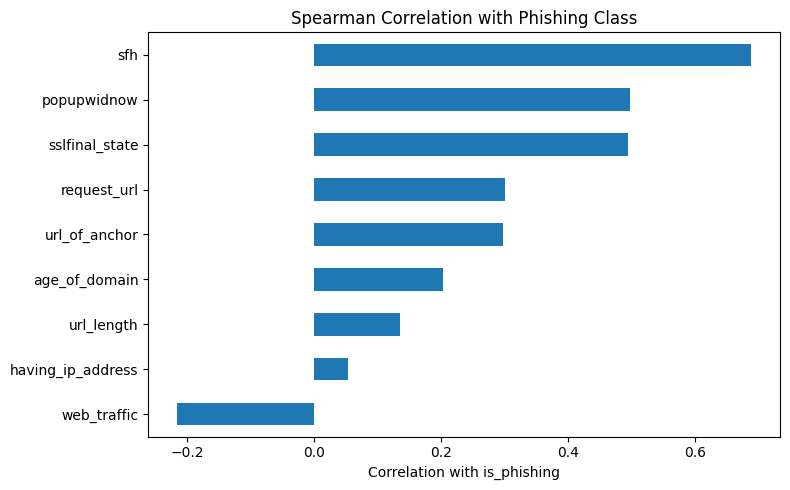

In [33]:
is_phishing = (df["result"] == -1).astype(int)

corr_table = pd.DataFrame({
    "Pearson": df[feature_columns].corrwith(is_phishing, method="pearson"),
    "Spearman": df[feature_columns].corrwith(is_phishing, method="spearman"),
    "Kendall": df[feature_columns].corrwith(is_phishing, method="kendall"),
})

corr_table["abs_spearman"] = corr_table["Spearman"].abs()
corr_table = corr_table.sort_values("abs_spearman", ascending=False)

display(corr_table.drop(columns="abs_spearman").round(3))

plt.figure(figsize=(8, 5))
corr_table["Spearman"].sort_values().plot(kind="barh")
plt.title("Spearman Correlation with Phishing Class")
plt.xlabel("Correlation with is_phishing")
plt.tight_layout()
plt.show()

## Correlation Findings

`sfh`, `popupwidnow`, and `sslfinal_state` show the strongest association with the phishing class. This is meaningful because these features describe security-relevant website behavior: server form handling, popup windows, and SSL status. The three correlation methods produce similar rankings, which increases confidence that these features contain useful signal.

Although the observed correlations are moderate rather than extremely strong, they are practically meaningful because phishing detection relies on combining multiple weak-to-moderate indicators rather than a single perfect feature.

# Section 8 — Feature Engineering

The dataset is already numerically encoded. The main preprocessing steps are target handling, train/test splitting, and scaling for models that benefit from scaled inputs.

In [34]:
# Separate features and target.
X = df.drop(columns=["result"])
y = df["result"]

# Train-test split with stratification to preserve the class distribution.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())
print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training set shape: (1082, 9)
Testing set shape: (271, 9)

Training class distribution:
result
-1    562
 0     82
 1    438
Name: count, dtype: int64

Testing class distribution:
result
-1    140
 0     21
 1    110
Name: count, dtype: int64


## Feature Engineering Decisions

No one-hot encoding was applied because the original dataset already uses compact ordinal encodings, and the original notebook treats the features as numerical inputs. MinMax scaling is applied inside the Logistic Regression pipeline because Logistic Regression is optimization-based and can be affected by feature scale. Random Forest and Decision Tree do not require scaling, but using the same train/test split ensures a fair comparison of inputs across models.

No dimensionality reduction was applied because there are only 9 features and interpretability is important in cybersecurity. Keeping the original features makes it easier to explain which website characteristics drive model predictions.

**Class weighting:** `class_weight="balanced"` is applied consistently to all three models in Section 9, so the minority `suspicious` class is treated the same way by every model. Without this, Logistic Regression would default to predicting the suspicious class 0% of the time (precision/recall/F1 all 0.00), which would make it look worse than it fairly is; with balanced weighting it correctly attempts the suspicious class (recall 0.48) at some cost to overall accuracy (see Section 9).

# Section 9 — Model Training and Evaluation

Three models are trained:

1. Logistic Regression — simple interpretable baseline.
2. Decision Tree — simple non-linear model.
3. Random Forest — an ensemble model similar in spirit to the original notebook's use of tree-based methods.

The evaluation uses weighted averages because the target classes are imbalanced. Confusion matrices and class-specific results are also included.

**Class weighting:** All three models use `class_weight="balanced"` to handle the class imbalance. The suspicious class has only 103 samples (7.6%), so without balancing, models tend to ignore it. This parameter makes scikit-learn adjust the penalty for each class inversely proportional to its frequency, applied consistently across all three models for a fair comparison.

## Evaluation Strategy

Several evaluation metrics are used because no single metric completely describes model performance. Accuracy provides an overall measure of correctness, while Precision and Recall capture different types of prediction errors. F1 and F2 summarize the balance between Precision and Recall, with F2 placing greater emphasis on Recall, which is particularly important for phishing detection. MCC provides a balanced evaluation that considers all entries of the confusion matrix, and ROC-AUC evaluates the model's ability to separate classes across different decision thresholds.

In cybersecurity, different types of prediction errors have different consequences. Missing a phishing website (false negative) is generally much more harmful than incorrectly flagging a legitimate website (false positive). Therefore, multiple complementary metrics are reported instead of relying on a single evaluation measure.

Regression metrics such as MAE, MSE, RMSE, and R² were not used because this is a multi-class classification problem rather than a regression task. Likewise, anomaly-detection metrics were not used because the models are supervised classifiers instead of unsupervised anomaly-detection methods.


## Evaluation Metrics Used

Because this is a multi-class classification task, most metrics are reported using **weighted averaging**, so each class contributes proportionally to its support in the test set.

For a single class, the basic quantities are:

- **TP**: samples of this class correctly predicted as this class.
- **FP**: samples from other classes incorrectly predicted as this class.
- **FN**: samples of this class incorrectly predicted as another class.
- **TN**: samples from other classes correctly not predicted as this class.

The metrics are:

- **Accuracy**: \((TP + TN) / (TP + TN + FP + FN)\). This measures the overall fraction of correct predictions.
- **Precision**: \(TP / (TP + FP)\). In phishing detection, low precision means many legitimate/suspicious websites are falsely flagged.
- **Recall**: \(TP / (TP + FN)\). For the phishing class, recall is critical because false negatives mean phishing pages are missed.
- **F1 Score**: \(2 \cdot \frac{precision \cdot recall}{precision + recall}\). This balances precision and recall equally.
- **F2 Score**: \((1+2^2) \cdot \frac{precision \cdot recall}{2^2 \cdot precision + recall}\). This weights recall more heavily than precision, which is useful in security problems.
- **Matthews Correlation Coefficient (MCC)**: a balanced correlation-like score between true and predicted labels. It is useful because it considers all parts of the confusion matrix.
- **ROC-AUC**: measures how well the model separates classes across decision thresholds. For this 3-class problem, one-vs-rest ROC-AUC with weighted averaging is used.


In [35]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", MinMaxScaler()),
        ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    )
}

results = []
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)
    predictions[name] = y_pred
    probabilities[name] = y_prob

    results.append(evaluate_model(name, y_test, y_pred, y_prob))

results_df = pd.DataFrame(results).set_index("Model")
display(results_df.round(4))

,Accuracy,Precision_weighted,Recall_weighted,F1_weighted,F2_weighted,MCC,ROC_AUC_weighted_OVR
Model,,,,,,,
Logistic Regression,0.7749,0.8370,0.7749,0.7997,0.7827,0.6301,0.9366
Decision Tree,0.8893,0.8911,0.8893,0.8896,0.8893,0.8054,0.9248
Random Forest,0.8893,0.8887,0.8893,0.8884,0.8888,0.8025,0.9752


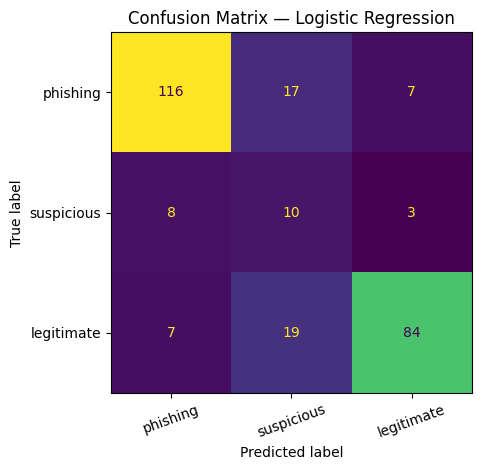

Classification report — Logistic Regression
              precision    recall  f1-score   support

    phishing       0.89      0.83      0.86       140
  suspicious       0.22      0.48      0.30        21
  legitimate       0.89      0.76      0.82       110

    accuracy                           0.77       271
   macro avg       0.67      0.69      0.66       271
weighted avg       0.84      0.77      0.80       271



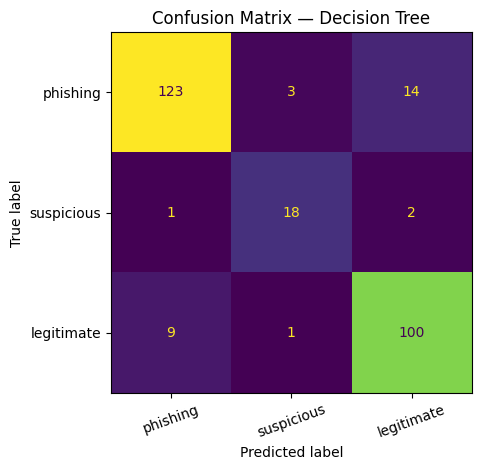

Classification report — Decision Tree
              precision    recall  f1-score   support

    phishing       0.92      0.88      0.90       140
  suspicious       0.82      0.86      0.84        21
  legitimate       0.86      0.91      0.88       110

    accuracy                           0.89       271
   macro avg       0.87      0.88      0.87       271
weighted avg       0.89      0.89      0.89       271



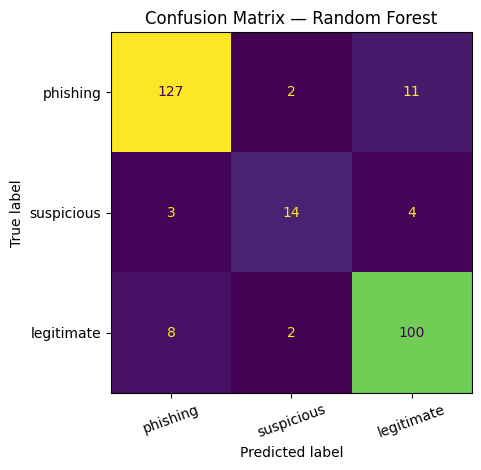

Classification report — Random Forest
              precision    recall  f1-score   support

    phishing       0.92      0.91      0.91       140
  suspicious       0.78      0.67      0.72        21
  legitimate       0.87      0.91      0.89       110

    accuracy                           0.89       271
   macro avg       0.86      0.83      0.84       271
weighted avg       0.89      0.89      0.89       271



In [36]:
# Confusion matrices.
labels = [-1, 0, 1]
display_labels = ["phishing", "suspicious", "legitimate"]

for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(cmap=None, colorbar=False)
    plt.title(f"Confusion Matrix — {name}")
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

    print(f"Classification report — {name}")
    print(classification_report(y_test, y_pred, labels=labels, target_names=display_labels, zero_division=0))

## Model Evaluation Findings

Random Forest and Decision Tree clearly outperform Logistic Regression (89% accuracy vs 77%), suggesting that the relationship between the encoded phishing indicators and the target class is not purely linear. With `class_weight="balanced"` applied consistently to all three models (Section 8), Logistic Regression's suspicious-class recall improves from 0.00 to 0.48, but its overall accuracy and MCC fall (accuracy 83.76%→77.49%, MCC 0.7040→0.6301) as it trades away phishing/legitimate accuracy to catch more suspicious cases. It still lags well behind the tree-based models on every metric.

On the single held-out test split, Random Forest and Decision Tree are very close, and not uniformly in Random Forest's favor: Decision Tree actually has a marginally **higher** weighted F1 (0.8896 vs 0.8884) and MCC (0.8054 vs 0.8025), and equal accuracy (0.8893). Random Forest's clear advantage is ROC-AUC (0.9752 vs 0.9248). With only 271 test samples, differences this small on F1/MCC are not strong evidence of a better model on their own. Random Forest is selected as the preferred model primarily because of its higher 5-fold cross-validation accuracy (89.28% vs 87.95% for Decision Tree, see Section 10), which is a more reliable estimate of generalization than a single split, together with its stronger ROC-AUC. This is a close call: Decision Tree remains a reasonable alternative, and notably achieves better recall on the suspicious class (0.86 vs 0.67 for Random Forest), which is relevant given that this project treats the suspicious class as particularly important.

The suspicious class is the hardest class to classify because it is small and conceptually ambiguous. In cybersecurity terms, suspicious websites may share features with both phishing and legitimate websites, so errors on this class are expected.

# Section 10 — Cross-Validation and Duplicate Sensitivity

A single train/test split can be unstable, especially on a small dataset. 5-fold stratified cross-validation is run to address this. The experiment is also repeated after removing exact duplicate rows to estimate how much duplicate records may inflate performance.

In [37]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    cv_results.append({
        "Model": name,
        "CV_accuracy_mean": scores.mean(),
        "CV_accuracy_std": scores.std(),
        "Fold_scores": np.round(scores, 4).tolist()
    })

cv_df = pd.DataFrame(cv_results).set_index("Model")
display(cv_df)

,CV_accuracy_mean,CV_accuracy_std,Fold_scores
Model,,,
Logistic Regression,0.771606,0.013509,"[0.7786, 0.7934, 0.7601, 0.7704, 0.7556]"
Decision Tree,0.879519,0.013437,"[0.8745, 0.8856, 0.8893, 0.8556, 0.8926]"
Random Forest,0.892822,0.017386,"[0.8745, 0.9004, 0.9151, 0.8704, 0.9037]"


In [38]:
# Duplicate-row sensitivity analysis.
df_dedup = df.drop_duplicates().copy()
X_dedup = df_dedup.drop(columns=["result"])
y_dedup = df_dedup["result"]

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_dedup, y_dedup,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_dedup
)

sensitivity_results = []
for name, model in models.items():
    model.fit(X_train_d, y_train_d)
    pred_d = model.predict(X_test_d)
    prob_d = model.predict_proba(X_test_d)
    sensitivity_results.append({
        "Model": name,
        "Accuracy_dedup": accuracy_score(y_test_d, pred_d),
        "F1_weighted_dedup": f1_score(y_test_d, pred_d, average="weighted", zero_division=0),
        "MCC_dedup": matthews_corrcoef(y_test_d, pred_d),
        "ROC_AUC_weighted_OVR_dedup": roc_auc_score(y_test_d, prob_d, multi_class="ovr", average="weighted")
    })

sensitivity_df = pd.DataFrame(sensitivity_results).set_index("Model")
print("Original rows:", df.shape[0])
print("Rows after removing exact duplicates:", df_dedup.shape[0])
display(sensitivity_df.round(4))

Original rows: 1353
Rows after removing exact duplicates: 724


,Accuracy_dedup,F1_weighted_dedup,MCC_dedup,ROC_AUC_weighted_OVR_dedup
Model,,,,
Logistic Regression,0.7103,0.7231,0.5324,0.8929
Decision Tree,0.7931,0.7917,0.6383,0.8248
Random Forest,0.7931,0.7887,0.6336,0.9131


## Cross-Validation and Duplicate Sensitivity Findings

Cross-validation confirms that Random Forest is consistently strong, but the duplicate-row sensitivity analysis shows that performance decreases after removing exact duplicate rows. This suggests that the original raw-data results may be somewhat optimistic. Duplicate rows can inflate estimated performance because identical feature patterns may appear in both the training and test sets after a random split. This makes the original test-set numbers somewhat optimistic.

# Section 11 — Feature Importance

Feature importance helps interpret what the Random Forest model learned. Both built-in impurity-based importance and permutation importance on the test set are reported.

,Feature,RandomForest_importance
0,sfh,0.2003
2,sslfinal_state,0.1857
3,request_url,0.1483
4,url_of_anchor,0.1468
6,url_length,0.1197
1,popupwidnow,0.0779
5,web_traffic,0.0750
7,age_of_domain,0.0333
8,having_ip_address,0.0129


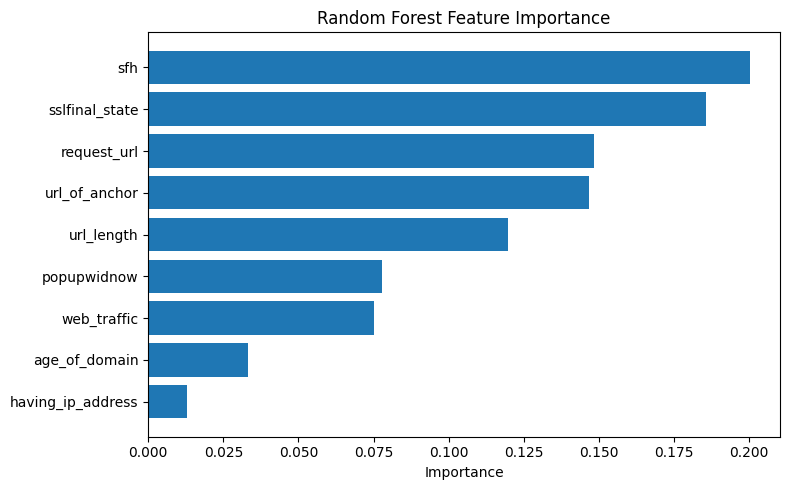

,Feature,Permutation_importance_mean,Permutation_importance_std
0,sfh,0.2247,0.0282
2,sslfinal_state,0.0797,0.0097
3,request_url,0.0600,0.0130
4,url_of_anchor,0.0504,0.0171
1,popupwidnow,0.0351,0.0088
6,url_length,0.0236,0.0121
5,web_traffic,0.0125,0.0091
8,having_ip_address,-0.0002,0.0014
7,age_of_domain,-0.0037,0.0072


In [19]:
rf_model = models["Random Forest"]
rf_model.fit(X_train, y_train)

importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "RandomForest_importance": rf_model.feature_importances_
}).sort_values("RandomForest_importance", ascending=False)

display(importance_df.round(4))

plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"][::-1], importance_df["RandomForest_importance"][::-1])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

perm = permutation_importance(rf_model, X_test, y_test, n_repeats=20, random_state=RANDOM_STATE, scoring="accuracy")
perm_df = pd.DataFrame({
    "Feature": feature_columns,
    "Permutation_importance_mean": perm.importances_mean,
    "Permutation_importance_std": perm.importances_std
}).sort_values("Permutation_importance_mean", ascending=False)

display(perm_df.round(4))

## Feature Importance Findings

The most important features are `sfh`, `sslfinal_state`, `request_url`, and `url_of_anchor`. This is consistent with cybersecurity intuition: form handling, SSL status, request URLs, and anchor links are directly related to how phishing websites collect information and disguise malicious behavior.

`having_ip_address` has low importance in this dataset. This does not mean IP addresses are never useful for phishing detection; rather, in this specific dataset, other features provide stronger signal.

# Section 12 — Error Analysis

Error analysis examines the cases where the selected Random Forest model fails. This is important because in phishing detection, false negatives are more dangerous than false positives.

In [20]:
rf_pred = predictions["Random Forest"]
error_df = X_test.copy()
error_df["true_label"] = y_test.values
error_df["predicted_label"] = rf_pred
error_df["true_name"] = error_df["true_label"].map(class_names)
error_df["predicted_name"] = error_df["predicted_label"].map(class_names)
error_df["correct"] = error_df["true_label"] == error_df["predicted_label"]

errors = error_df[~error_df["correct"]]
false_negatives_phishing = error_df[(error_df["true_label"] == -1) & (error_df["predicted_label"] != -1)]
false_positives_phishing = error_df[(error_df["true_label"] != -1) & (error_df["predicted_label"] == -1)]

print("Total test samples:", len(error_df))
print("Total errors:", len(errors))
print("Phishing false negatives (actual phishing predicted as another class):", len(false_negatives_phishing))
print("Phishing false positives (non-phishing predicted as phishing):", len(false_positives_phishing))

print("\nError type counts:")
display(pd.crosstab(errors["true_name"], errors["predicted_name"], rownames=["true"], colnames=["predicted"]))

print("\nMean feature values for correct vs incorrect predictions:")
display(error_df.groupby("correct")[feature_columns].mean().round(3))

print("\nSample misclassified rows:")
display(errors.head(10))

Total test samples: 271
Total errors: 30
Phishing false negatives (actual phishing predicted as another class): 13
Phishing false positives (non-phishing predicted as phishing): 11

Error type counts:


predicted,legitimate,phishing,suspicious
true,,,
legitimate,0,8,2
phishing,11,0,2
suspicious,4,3,0



Mean feature values for correct vs incorrect predictions:


,sfh,popupwidnow,sslfinal_state,request_url,url_of_anchor,web_traffic,url_length,age_of_domain,having_ip_address
correct,,,,,,,,,
False,-0.133,-0.667,0.433,-0.433,-0.167,0.167,0.067,0.333,0.100
True,0.220,-0.158,0.365,-0.191,-0.046,0.033,-0.100,0.245,0.108



Sample misclassified rows:


,sfh,popupwidnow,sslfinal_state,request_url,url_of_anchor,web_traffic,url_length,age_of_domain,having_ip_address,true_label,predicted_label,true_name,predicted_name,correct
12,1,-1,0,-1,1,0,1,1,0,1,-1,legitimate,phishing,False
893,-1,-1,0,-1,1,-1,1,1,0,-1,1,phishing,legitimate,False
816,1,0,1,-1,0,0,-1,1,0,0,-1,suspicious,phishing,False
308,1,-1,0,1,0,1,0,1,0,-1,1,phishing,legitimate,False
277,-1,-1,1,-1,0,1,0,-1,0,-1,1,phishing,legitimate,False
494,-1,-1,1,0,0,1,-1,-1,0,1,-1,legitimate,phishing,False
1345,-1,0,1,-1,1,0,-1,1,0,0,1,suspicious,legitimate,False
1063,-1,-1,1,-1,0,1,-1,-1,0,-1,1,phishing,legitimate,False
1177,1,0,-1,-1,1,1,1,-1,0,0,-1,suspicious,phishing,False
915,-1,0,1,-1,0,-1,1,1,0,-1,0,phishing,suspicious,False


## Error Analysis Findings

The most important error type in phishing detection is a phishing false negative: a phishing website predicted as suspicious or legitimate. These cases are dangerous because the user may not be warned. The Random Forest model reduces this risk compared with Logistic Regression, but it does not eliminate it.

Many errors involve the suspicious class, which is expected because suspicious websites are inherently ambiguous: they contain some phishing-like and some legitimate-like characteristics.

The results illustrate the practical trade-off between false positives and false negatives. Reducing false negatives generally requires the model to classify more websites as phishing, which can increase the number of false positives. In a cybersecurity setting, this trade-off is usually acceptable because incorrectly warning about a legitimate website is typically less harmful than allowing a phishing website to remain undetected. Therefore, deployment would generally favor higher phishing recall, even at the cost of a moderate increase in false positives.


# Section 13 — Executive Summary

This project reproduced and critically evaluated the Kaggle notebook *Website Phishing Detection ML Project* by **duygujones** using the **Website Phishing** dataset, which contains **1,353** website samples, **9** predictive features, and a **3-class** target (phishing, suspicious, and legitimate).

The project followed a complete machine learning workflow consisting of data loading and inspection, exploratory data analysis, feature engineering, supervised model training, evaluation using multiple complementary performance metrics, feature importance analysis, and detailed error analysis. Three classification models were trained and compared: Logistic Regression, Decision Tree, and Random Forest, all using consistent `class_weight="balanced"` settings (Section 8).

Random Forest was selected as the preferred model, obtaining **88.93% accuracy**, **0.8025 MCC**, and **97.52% weighted ROC-AUC**, along with the highest 5-fold cross-validation accuracy (89.28%) of the three models. Decision Tree was very close on the single held-out test split — slightly higher weighted F1 and MCC, and better recall on the suspicious class — so Random Forest's selection rests mainly on its cross-validated stability and stronger ROC-AUC rather than a decisive advantage on every metric. Logistic Regression trailed both tree-based models by a wide margin (77.49% accuracy, 0.6301 MCC); with balanced class weighting it now predicts the suspicious class at all (recall improves from 0.00 to 0.48) at some cost to overall accuracy, confirming that its earlier apparent competitiveness came partly from ignoring the minority class. The analysis also revealed important limitations of the dataset. It contains **629 duplicate rows**, several identical feature patterns with conflicting class labels, and a relatively small suspicious class. A duplicate-aware sensitivity analysis showed that model performance decreases after removing duplicate records, indicating that the original evaluation is somewhat optimistic.

The analysis identified **`sfh`**, **`sslfinal_state`**, **`request_url`**, and **`url_of_anchor`** as the most influential features. These characteristics are directly related to common phishing techniques, including deceptive form handling, SSL misuse, and malicious hyperlinks.

Overall, this project demonstrates that effective phishing detection depends not only on selecting a strong machine learning model but also on careful data inspection, appropriate feature engineering, rigorous evaluation, and critical analysis of the dataset. The reproduction confirms the usefulness of machine learning for phishing detection while highlighting the importance of data quality, duplicate analysis, class imbalance, and cybersecurity-oriented evaluation when interpreting model performance.


# Section 14 — Summing It Up

This project successfully reproduced and critically evaluated the Kaggle notebook *Website Phishing Detection ML Project* by duygujones.

The reproduction confirms that the overall machine learning approach is appropriate for phishing website detection. Random Forest consistently outperformed Logistic Regression, indicating that non-linear relationships between the phishing indicators are important for accurate classification.

The author's main claim—that machine learning can effectively distinguish phishing websites from legitimate ones—is supported by the reproduced results. However, the original notebook omits several important aspects of a rigorous machine learning workflow. It does not discuss duplicate records, the minority suspicious class, feature engineering decisions, cybersecurity implications of the evaluation metrics, or detailed error analysis. These omissions reduce the transparency and reproducibility of the original work.

The additional analyses performed in this project, including exploratory data analysis, correlation analysis, feature importance analysis, class balance analysis, and error analysis, provide a more complete understanding of both the dataset and the model behaviour.

This project is recommended as an educational example or as a starting point for phishing detection research because its methodology is simple, interpretable, and produces strong results. However, it should not be deployed directly in a real cybersecurity system without further validation on larger and more recent datasets, additional robustness testing, and threshold optimization.

Overall, this reproduction demonstrates that successful phishing detection depends not only on selecting a strong machine learning model but also on careful data inspection, appropriate evaluation metrics, rigorous validation, and critical analysis of the original methodology.
